In [ ]:
# Carregamento e visualização dos dados
import pandas as pd
import  numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Titanic_train.csv')

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Verificando valores faltantes

data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

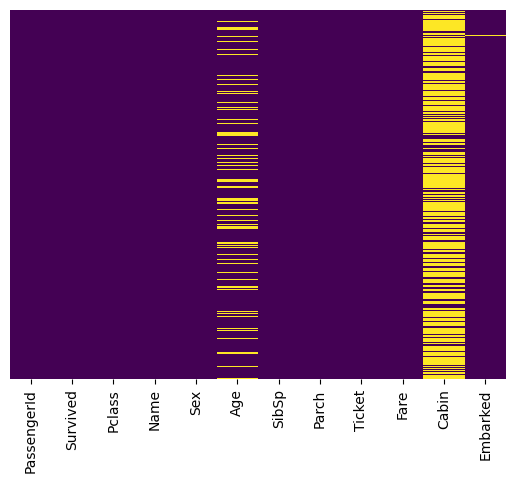

In [ ]:
# Mapa de calor seaborn

sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
# Tratamento de dados Faltantes (idade)
# Calcular a mediana da idade
age_median = data['Age'].median()
# Atribuir a mediana diretamente ao DataFrame
data['Age'] = data['Age'].fillna(age_median)

# Tratamento de dados faltantes (cabine)
data.drop(columns=['Cabin'], inplace=True)  # Cabine tem muitos dados faltantes



KeyError: "['Cabin'] not found in axis"

In [ ]:
# Verificando valores faltantes
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Por fim, faltam esses dois passageiros que não possuem onde foram embarcados...  Vamos simplesmente deletar esses registros.


In [ ]:
data.dropna(inplace=True)

In [ ]:
# Verificando valores faltantes
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Etapa 2: Análise Exploratória de Dados (EDA)



In [ ]:
# Estatísticas descritivas

data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


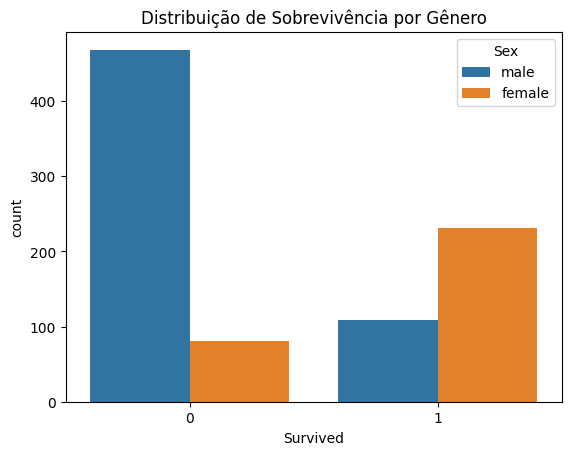

In [ ]:
# Distribuição de sobreviventes por gênero
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Distribuição de Sobrevivência por Gênero')
plt.show()

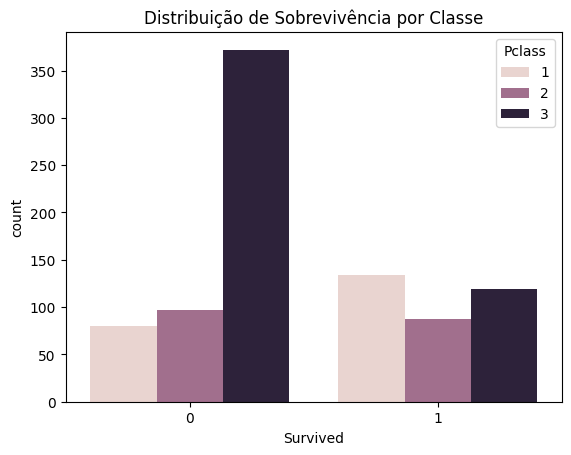

In [ ]:
# Distribuição de sobreviventes por classe de passageiro
sns.countplot(x='Survived', hue='Pclass', data=data)
plt.title('Distribuição de Sobrevivência por Classe')
plt.show()

### Etapa 3: Análise Mais Profunda

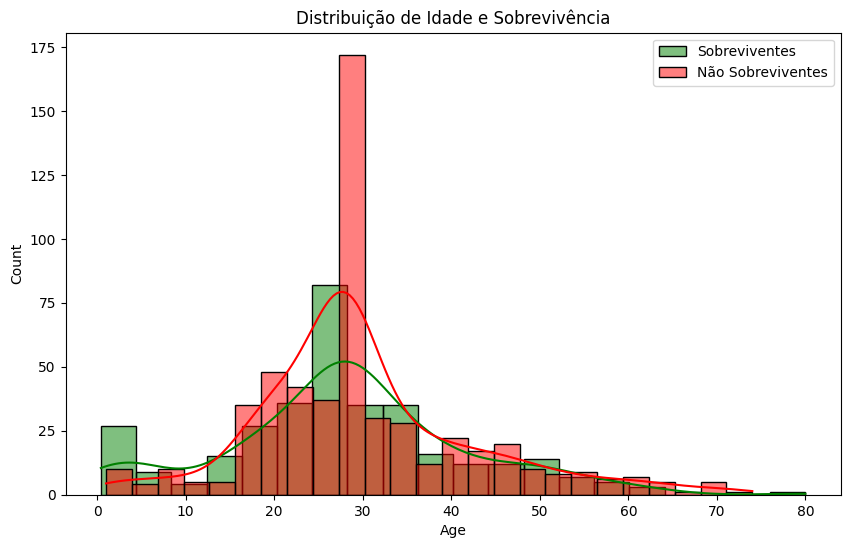

In [ ]:
# Análise da idade dos passageiros e sua relação com a sobrevivência
plt.figure(figsize=(10, 6))
sns.histplot(data[data['Survived'] == 1]['Age'], color='green', kde=True, label='Sobreviventes')
sns.histplot(data[data['Survived'] == 0]['Age'], color='red', kde=True, label='Não Sobreviventes')
plt.title('Distribuição de Idade e Sobrevivência')
plt.legend()
plt.show()

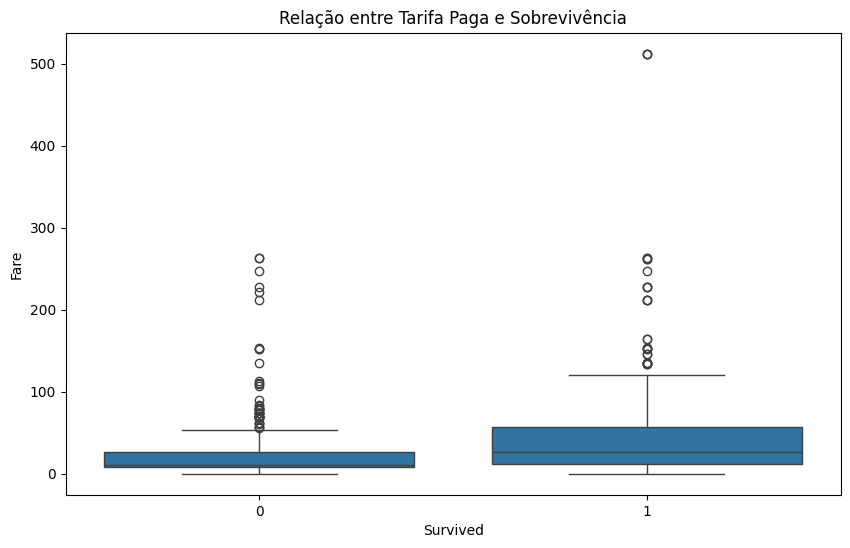

In [ ]:
# Análise da tarifa paga e sobrevivência
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=data)
plt.title('Relação entre Tarifa Paga e Sobrevivência')
plt.show()

### Etapa 4: Correlações e Análises dos Dados

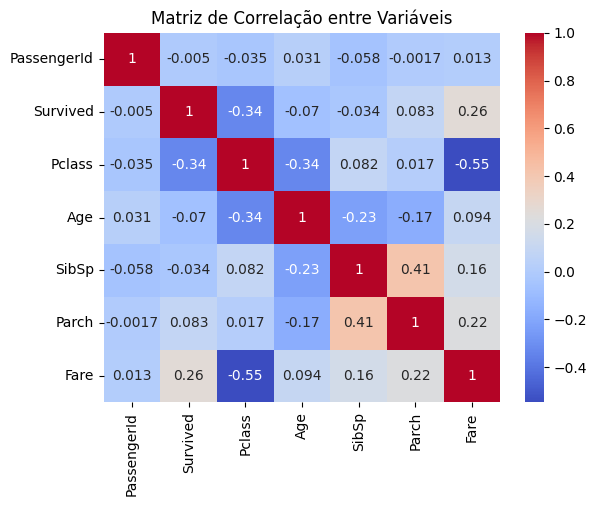

In [ ]:
# Matriz de correlação
correlation = data.select_dtypes(include=np.number).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

### Discussão sobre as Descobertas
1. **Impacto do Gênero na Sobrevivência**   A análise inicial revela uma distinção clara nas taxas de sobrevivência entre homens e mulheres. Os gráficos indicam que uma proporção significativamente maior de mulheres sobreviveu em comparação com os homens. *Isso pode ser atribuído a políticas de evacuação prioritária como "mulheres e crianças primeiro", que eram comuns em desastres náuticos naquela época.*

2. **Classe como Fator de Sobrevivência** Os dados mostram que os passageiros da primeira classe tiveram uma taxa de sobrevivência significativamente maior em comparação com as outras classes. *Isso sugere que fatores socioeconômicos, como a localização das cabines e o acesso a botes salva-vidas, desempenharam um papel crucial na sobrevivência dos passageiros.*

3. **Relação entre Idade e Sobrevivência** A distribuição de idade dos sobreviventes versus não sobreviventes indica que crianças e idosos foram mais propensos a sobreviver. *Este padrão também apoia a ideia de priorização de mulheres e crianças durante os procedimentos de evacuação e pode indicar uma tendência de proteção aos mais vulneráveis em situações de emergência.*

4. **Influência da Tarifa na Sobrevivência** A análise das tarifas pagas mostra que passageiros que pagaram tarifas mais altas, geralmente relacionadas a cabines de classe superior, tiveram melhores chances de sobrevivência. *Isso pode estar correlacionado com a proximidade dessas cabines aos botes salva-vidas e com o melhor atendimento durante a emergência.*

5. **Correlações Gerais** A matriz de correlação ajudou a confirmar algumas dessas observações, mostrando correlações positivas entre a sobrevivência e fatores como tarifa paga e classe do passageiro. Por outro lado, a idade parece ter uma correlação menos direta, indicando que outros fatores interpessoais e de decisão durante o desastre podem ter influenciado os resultados de sobrevivência.

### Conclusões
Os insights obtidos com este projeto de análise de dados não apenas ajudam a entender melhor o trágico evento do Titanic, mas também oferecem lições valiosas sobre a gestão de emergências e o design de medidas de segurança em transportes. As descobertas podem ser utilizadas para melhorar as práticas atuais em segurança de transportes, garantindo que medidas de proteção sejam justas e eficazes para todos os passageiros, independentemente de gênero, idade ou status socioeconômico.
